# MLPKriging — Deep Kernel Learning (Julia)

**MLPKriging** combines a multi-layer perceptron (MLP) feature map with Gaussian-process
regression. The MLP takes *all* input dimensions jointly and maps them into a learned
`d_out`-dimensional feature space, after which a standard Kriging model is fitted.
This is also known as *Deep Kernel Learning*.

Steps:
1. Setup jlibkriging
2. Define the Branin function and plot it
3. Build a space-filling design and evaluate it
4. Fit an `MLPKriging` model
5. Predict on a fine grid and plot mean + uncertainty
6. Inspect model parameters

## 0. Setup jlibkriging

Make sure the `jlibkriging` Julia package is available and the shared library
(`libkriging_c.so` / `.dylib`) is built. Adjust `JLIBKRIGING_LIB_PATH` if needed.

In [1]:
using Pkg

# Point to the built shared library
ENV["JLIBKRIGING_LIB_PATH"] = joinpath(abspath(joinpath(pwd(), "..", "..")), "build", "bindings", "Julia", "jlibkriging", "libkriging_c.so")

# Activate the jlibkriging project from the repo
repo_root = abspath(joinpath(pwd(), "..", ".."))
Pkg.activate(joinpath(repo_root, "bindings", "Julia", "jlibkriging"))

using jlibkriging
using Plots; gr()
using Random

  Activating 

project at `~/Sync/Open/libKriging/alien/libKriging/bindings/Julia/jlibkriging`


## 1. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).

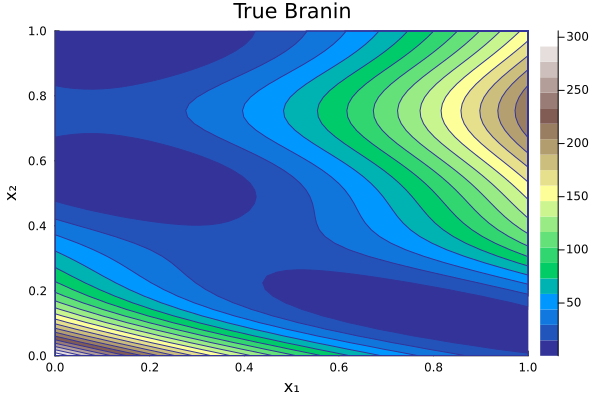

In [2]:
function branin(X::AbstractMatrix)
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    @. (x2 - 5 / (4π^2) * x1^2 + 5/π * x1 - 6)^2 +
       10 * (1 - 1/(8π)) * cos(x1) + 10
end

grid_x = range(0, 1, length=50)
G1 = repeat(collect(grid_x), 1, 50)
G2 = repeat(collect(grid_x)', 50, 1)
grid_pts = hcat(vec(G1), vec(G2))
z_true = reshape(branin(grid_pts), 50, 50)

contourf(collect(grid_x), collect(grid_x), z_true,
         levels=20, color=:terrain,
         title="True Branin", xlabel="x₁", ylabel="x₂")

## 2. Design of experiments

We sample $n = 30$ points using a simple Latin Hypercube.

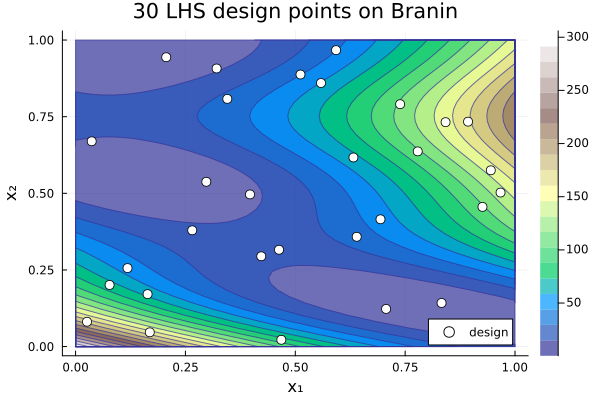

In [3]:
Random.seed!(42)

function lhs(n, d)
    X = zeros(n, d)
    for j in 1:d
        perm = randperm(n)
        X[:, j] = (perm .- 1 .+ rand(n)) ./ n
    end
    X
end

n = 30
X = lhs(n, 2)
y = branin(X)

p = contourf(collect(grid_x), collect(grid_x), z_true,
             levels=20, color=:terrain, alpha=0.7,
             title="$n LHS design points on Branin",
             xlabel="x₁", ylabel="x₂")
scatter!(p, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=5, label="design")

## 3. Fit an MLPKriging model

We use `hidden_dims=[16, 8]` (two hidden layers), `d_out=2` (2D feature space),
and `activation="selu"`.

In [4]:
mk = MLPKriging(y, X, [16, 8], 2;
                activation="selu", kernel="matern5_2",
                optim="BFGS+Adam")
println(jlibkriging.summary(mk))

* MLPKriging
  - kernel:      matern5_2
  - regmodel:    constant
  - normalize:   false
  - n obs:       30
  - d input:     2
  - d features:  2
  - warping:     MLPJoint(2 -> 16 -> 8 -> 2, 202 params)
  - sigma2:      2732.75
  - theta:          0.0556   0.0190
  - beta:           66.2617
  - LL:          -159.319
  - total warp params: 202



## 4. Predict on a fine grid

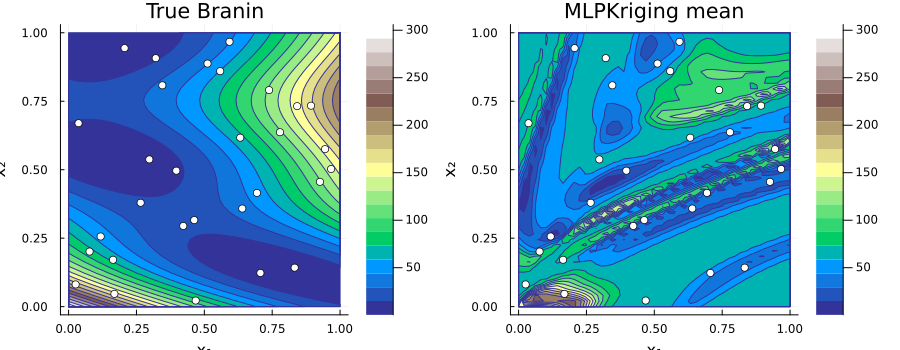

In [5]:
pred   = predict(mk, grid_pts; return_stdev=true)
z_mean = reshape(pred.mean, 50, 50)
z_sd   = reshape(pred.stdev, 50, 50)

vmin = min(minimum(z_true), minimum(z_mean))
vmax = max(maximum(z_true), maximum(z_mean))

p1 = contourf(collect(grid_x), collect(grid_x), z_true,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="True Branin", xlabel="x₁", ylabel="x₂")
scatter!(p1, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

p2 = contourf(collect(grid_x), collect(grid_x), z_mean,
              levels=20, color=:terrain, clims=(vmin, vmax),
              title="MLPKriging mean", xlabel="x₁", ylabel="x₂")
scatter!(p2, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=4, label="")

plot(p1, p2, layout=(1, 2), size=(900, 350))

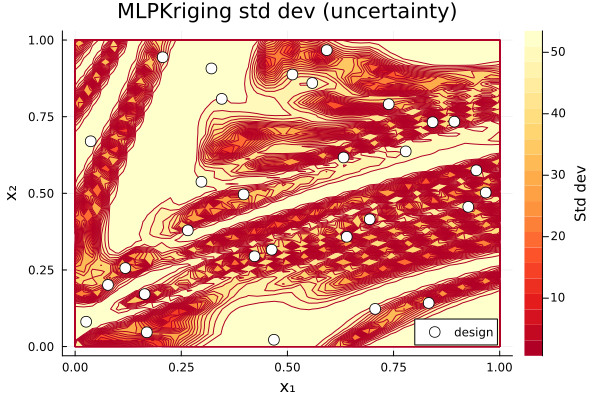

In [6]:
# Posterior standard deviation (uncertainty)
p = contourf(collect(grid_x), collect(grid_x), z_sd,
             levels=20, color=cgrad(:YlOrRd, rev=true),
             title="MLPKriging std dev (uncertainty)",
             xlabel="x₁", ylabel="x₂", colorbar_title="Std dev")
scatter!(p, X[:, 1], X[:, 2], mc=:white, msc=:black, ms=6, label="design")

## 5. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood,
hidden layer architecture, and activation function.

In [7]:
println("Kernel       : ", kernel(mk))
println("Theta (range): ", round.(get_theta(mk), digits=4))
println("Sigma2       : ", round(get_sigma2(mk), digits=4))
println("LogLikelihood: ", round(log_likelihood(mk), digits=4))
println("Feature dim  : ", feature_dim(mk))
println("Hidden dims  : ", get_hidden_dims(mk))
println("Activation   : ", activation(mk))

Kernel       : matern5_2
Theta (range): 

[0.0556, 0.019]
Sigma2       : 2732.7474
LogLikelihood: -159.3194
Feature dim  : 

2
Hidden dims  : 

[16, 8]
Activation   : selu
